# HW 1
Jon Pulsipher, 6017, 5/16/26

### Exercise 1 - Creating Cells, Executing Code

1) Create a new code cell below where you define variables containing your name, your age in years, and your major.
2) Create another cell that uses these variables and prints a concatenated string stating your name, major, and your age in years, months, and days (assuming today is your birthday ;)). The output should look like that:
```
Name: Science Cat, Major: Computer Science, Age: 94 years, or 1128 months, or 34310 days.
```


In [16]:
name, age, major = "Jonathan Pulsipher", 37, "Software Development"
print("Name: " + name + ", Major: " + major + ", Age: " + str(age) + " years, or " + str(age * 12) + " months, or " + str(age * 365 + 1 * int(age / 4)) + " days.") #to account for leap year

Name: Jonathan Pulsipher, Major: Software Development, Age: 37 years, or 444 months, or 13514 days.


### Exercise 2 - Sets

Write a function that finds the overlap of two sets and prints them. Initialize two sets, e.g., with values {13, 25, 37, 45, 13} and {14, 25, 38, 8, 45} and call this function with them.

In [17]:
set1, set2 = {13, 25, 37, 45, 13}, {14, 25, 38, 8, 45}
overlap = set([x for x in set1 if x in set2])
print(overlap)

{25, 45}


### Exercise 4 - Pandas Series

Create a new pandas series with the lists given below that contain NFL team names and the number of Super Bowl titles they won. Use the names as indices, the wins as the data.

- Once the list is created, sort the series alphabetically by index.
- Print an overview of the statistical properties of the series. What's the mean number of wins?
- Filter out all teams that have won less than four Super Bowl titles
- A football team has 45 players. Update the series so that instead of the number of titles, it reflects the number of Super Bowl rings given to the players.
- Assume that each ring costs $30000. Update the series so that it includes a string of the dollar amount including the sign. For the Steelers, for example, this would correspond to:

In [18]:
import pandas as pd

teams = ["Pittsburgh Steelers",
"New England Patriots",
"Dallas Cowboys",
"San Francisco 49ers",
"Green Bay Packers",
"New York Giants",
"Denver Broncos",
"Oakland/Los Angeles Raiders",
"Washington Redskins",
"Miami Dolphins",
"Baltimore/Indianapolis Colts",
"Baltimore Ravens"]
wins = [6,6,5,5,4,4,3,3,3,2,2,2]

teamWins = pd.Series(wins, index=teams).sort_index()
print(f"Team data series \n\tCount: {teamWins.count()} \
      \n\tMean: {teamWins.mean()} \
      \n\tMedian: {teamWins.median()} \
      \n\tMax: {teamWins.max()} for index \"{teamWins.idxmax()}\" \
      \n\tMin: {teamWins.min()} for index \"{teamWins.idxmin()}\"")
won4Mask = teamWins >= 4
print(teamWins[won4Mask])

Team data series 
	Count: 12       
	Mean: 3.75       
	Median: 3.5       
	Max: 6 for index "New England Patriots"       
	Min: 2 for index "Baltimore Ravens"
Dallas Cowboys          5
Green Bay Packers       4
New England Patriots    6
New York Giants         4
Pittsburgh Steelers     6
San Francisco 49ers     5
dtype: int64


In [19]:

teamRings = teamWins * 45
print(teamRings)

Baltimore Ravens                 90
Baltimore/Indianapolis Colts     90
Dallas Cowboys                  225
Denver Broncos                  135
Green Bay Packers               180
Miami Dolphins                   90
New England Patriots            270
New York Giants                 180
Oakland/Los Angeles Raiders     135
Pittsburgh Steelers             270
San Francisco 49ers             225
Washington Redskins             135
dtype: int64


In [20]:
teamRingCost = teamRings.apply(lambda x: f"$ {x * 30000}") 
print(teamRingCost)


Baltimore Ravens                $ 2700000
Baltimore/Indianapolis Colts    $ 2700000
Dallas Cowboys                  $ 6750000
Denver Broncos                  $ 4050000
Green Bay Packers               $ 5400000
Miami Dolphins                  $ 2700000
New England Patriots            $ 8100000
New York Giants                 $ 5400000
Oakland/Los Angeles Raiders     $ 4050000
Pittsburgh Steelers             $ 8100000
San Francisco 49ers             $ 6750000
Washington Redskins             $ 4050000
dtype: str


### Data Exploration/Analysis
Load and prepare annual data for one station



In [21]:
import pandas as pd
import matplotlib.pyplot as plt

aqDFRaw = pd.read_csv("2025-PM2.5.csv", 
                       header = [0,1,2],
                       index_col = 0)

#Selecting "Hawthorne" because it is downtown SLC and may have more interesting data
#Selecting using multi-header tuple
hawthStation = aqDFRaw[("H3", "MC", "UG/M3")]
hawthStation.name = "hawthorne station"

#convert station dates to datetime objects and drop empties
hawthStation.index = pd.to_datetime(hawthStation.index, format="%d-%b-%Y %H:%M")
hawthStation.dropna()
hawthStation.head(3)

2025-01-01 00:00:00    13.1
2025-01-01 01:00:00     4.0
2025-01-01 02:00:00     3.8
Name: hawthorne station, dtype: float64

#### "Plot the readings from that station over the course of a year"

Text(0, 0.5, 'PM2.5 (µg/m³)')

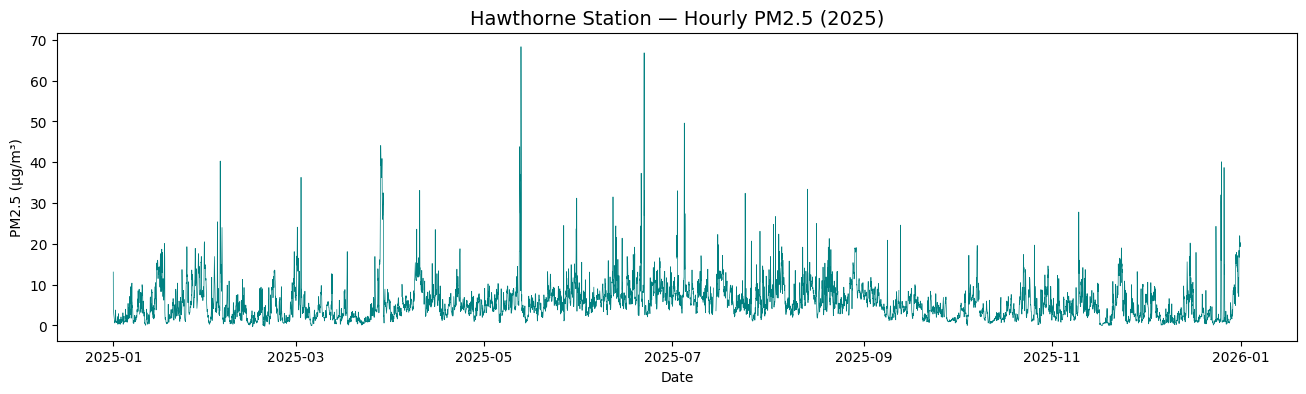

In [22]:
fig, ax = plt.subplots(figsize = (16,4))
ax.plot(hawthStation.index, hawthStation.values, linewidth=0.5, color="teal")

ax.set_title("Hawthorne Station — Hourly PM2.5 (2025)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 (µg/m³)")

#### "Plot the mean pm2.5 level for each month using a bar chart. Note any insights you can gain from this visualization."

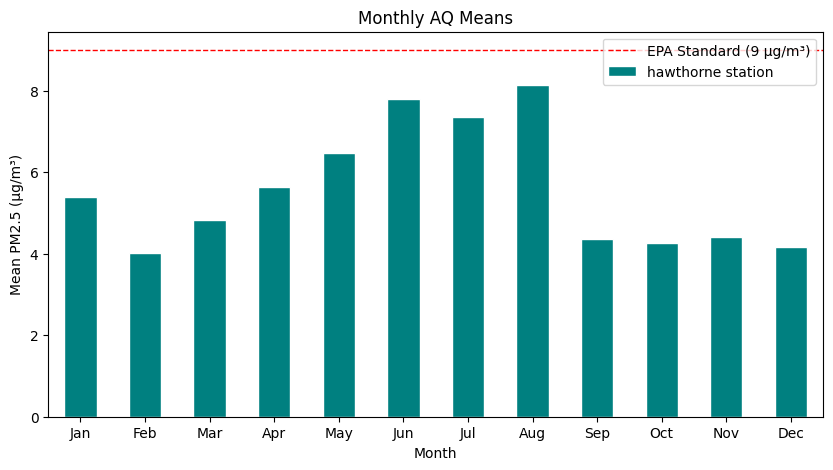

In [23]:
#Group station data by monts
monthly_mean = hawthStation.groupby(hawthStation.index.month).mean()

#Label it
monthly_mean.index = ["Jan","Feb","Mar","Apr","May","Jun",
                       "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10,5))

monthly_mean.plot(kind="bar", ax=ax, color="teal", edgecolor="white")

ax.set_title("Monthly AQ Means")
ax.set_xlabel("Month")
ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.tick_params('x', rotation=0)

# Draw the EPA 24-hr standard as a reference line
ax.axhline(y=9, color="red", linestyle="--", linewidth=1, label="EPA Standard (9 µg/m³)")
ax.legend()

# plt.tight_layout()
plt.show()

#### *What insights can we draw from this map?*

My expectations for an AQI graph in downtown Salt Lake City would be that
1) AQI is worse than EPA standards
2) AQI is worse in the winter, when inversion is present

That is not what this graph is showing, with higher measurements in the summer and all measurements below the EPA limit. In addition to this mismatch of expectations, the current Salt Lake City AQI is 26 (5/17/26) -- triple any of these measurements. From inspection, the Hawthorne station also doesn't seem to be an outlier compared to the other stations. I expect there is a discrepancy between how we are managing this data and how the EPA limit and the current reported AQI manage their data.

#### "Plot the mean pollution level for each hour"

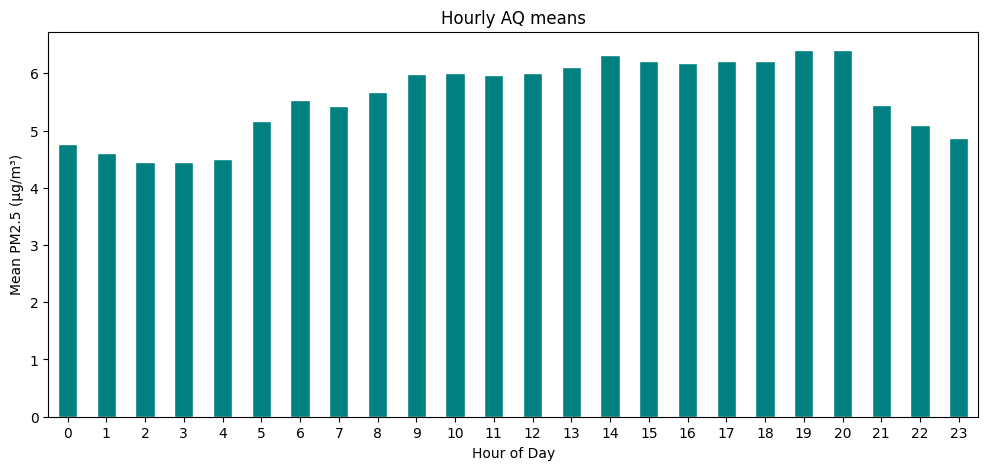

In [24]:
hourly_mean = hawthStation.groupby(hawthStation.index.hour).mean()

fig, ax = plt.subplots(figsize=(12,5))

hourly_mean.plot(kind="bar", ax=ax, color="teal", edgecolor="white")

ax.set_title("Hourly AQ means")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.tick_params('x', rotation=0)


#### What insights can you draw from this view of the data?
We see a clear difference in air quality between "day" and "night" that matches what we would expect from increased activity, especially driving, during the day. This peaks from the hours of 9am to 8pm (with a ramp from 5am - 9am), with a corresponding low period from 11pm to 4am.

#### "Use Box and Whisker plots of the monthly and hourly data groupings to provide a more complete view of the data."
We'll start with the monthly Box and Whisker plot.

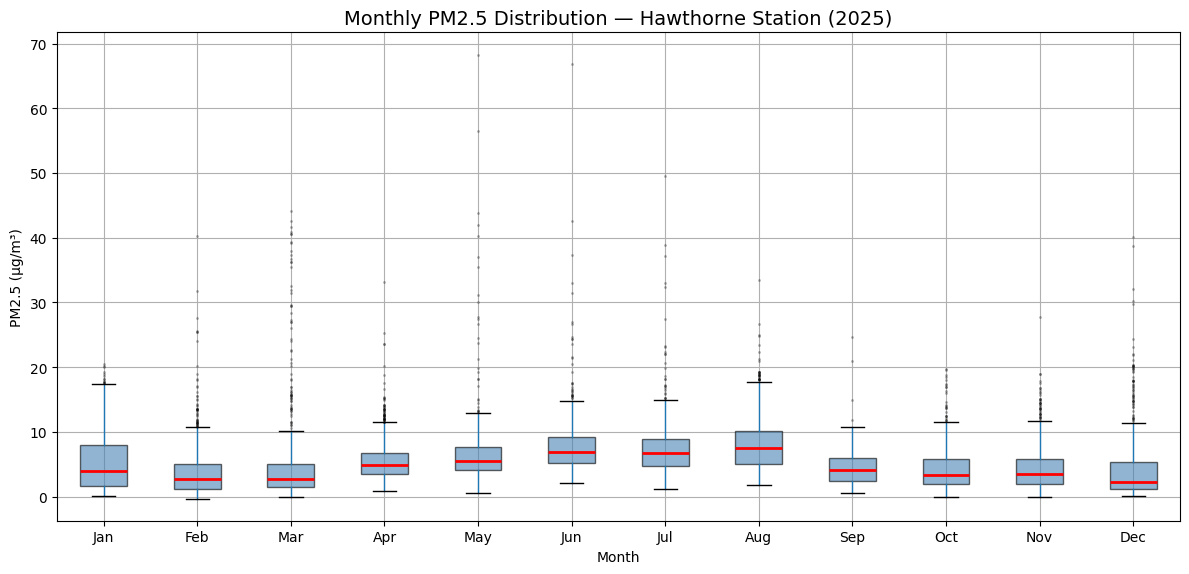

In [25]:
hawthStation.groupby(hawthStation.index.month).apply(list)

df_station = hawthStation.to_frame()
df_station["month"] = hawthStation.index.month
df_station["month_name"] = hawthStation.index.strftime("%b") 

# We start by applying a custom order based on fixed month order to the data before plotting it
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
df_station["month_name"] = pd.Categorical(
    df_station["month_name"],
    categories=month_order,
    ordered=True
)
df_station = df_station.sort_values("month_name")

fig, ax = plt.subplots(figsize=(12, 6))

df_station.boxplot(
    column="hawthorne station",
    by="month_name",
    ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    medianprops=dict(color="red", linewidth=2),
    flierprops=dict(marker=".", markersize=2, alpha=0.3)
)

ax.set_title("Monthly PM2.5 Distribution — Hawthorne Station (2025)", fontsize=14)
plt.suptitle("")
ax.set_xlabel("Month")
ax.set_ylabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

#### Does this depection of the data give us any more insights?
The higher upper quartile in January gives us a potential candidate for what we'd expect from the occasional winter-month inversion peaks in poor air quality. 

#### And by Hour


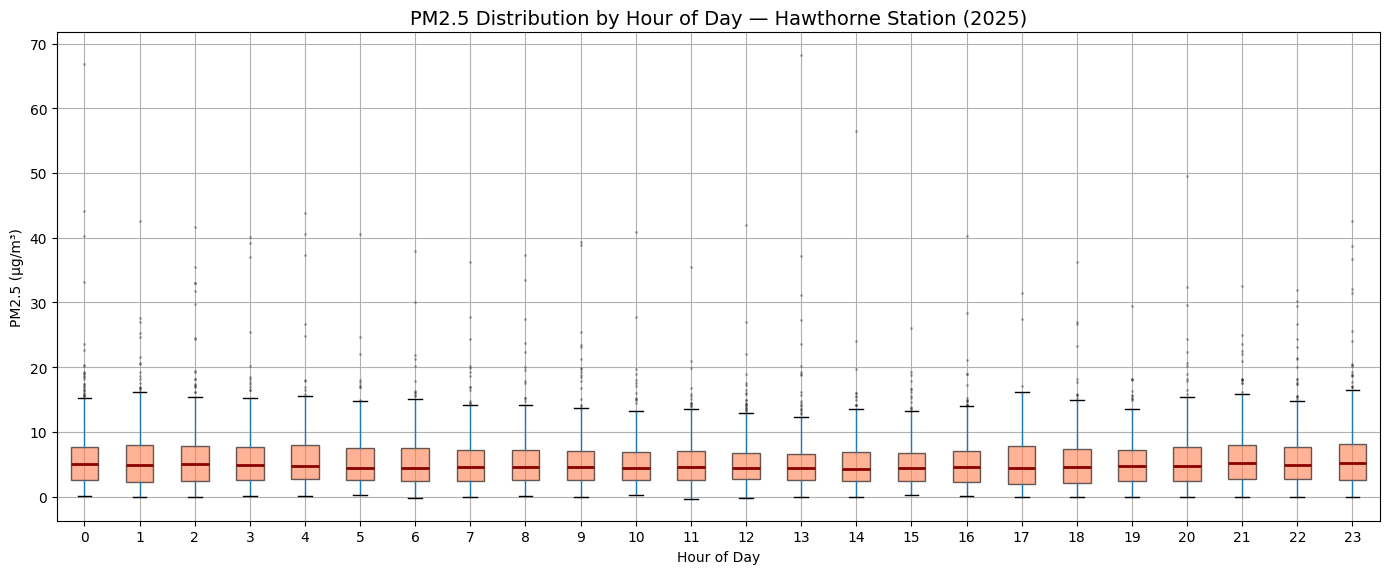

In [26]:
df_station["hour"] = hawthStation.index.hour

fig, ax = plt.subplots(figsize=(14, 6))

df_station.boxplot(
    column="hawthorne station",
    by="hour",
    ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor="coral", alpha=0.6),
    medianprops=dict(color="darkred", linewidth=2),
    flierprops=dict(marker=".", markersize=2, alpha=0.3)
)

ax.set_title("PM2.5 Distribution by Hour of Day — Hawthorne Station (2025)", fontsize=14)
plt.suptitle("")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

#### Does this depection of the data give us any more insights?
The taller y-axis makes it harder to distinguish the mean averages by sight. Are there other insights beyond 'worse AQI during day' that we can infer from this? Perhaps that, at least around this station, the daytime hours of 7am, 10am, 12-2pm are more active than the other hours (early morning commute pressure + lunch hour?) And that 1am, 2am, 4am, and 5am are more active hours in their upper quartile than other nighttime hours.